# 2.3.2: Apparel Classification — VGG16

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.applications import VGG16 # type: ignore
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

## Load & Preprocess Images

In [3]:
IMG_SIZE = 224
DATA_DIR = 'data/apparel/dataset'
classes = sorted(os.listdir(DATA_DIR))
print(f'Classes: {classes}')

images = []
labels = []

for idx, cls in enumerate(classes):
    cls_dir = os.path.join(DATA_DIR, cls)
    for fname in os.listdir(cls_dir):
        fpath = os.path.join(cls_dir, fname)
        img = cv2.imread(fpath)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        images.append(img)
        labels.append(idx)

X = np.array(images, dtype='float32')
y = np.array(labels)

# Use VGG16 preprocessing instead of /255
X = preprocess_input(X)
print(f'Total images: {X.shape[0]}, Shape: {X.shape}')
print(f'Label distribution: {dict(zip(*np.unique(y, return_counts=True)))}')

Classes: ['dress', 'pants', 'shirt', 'shoes']
Total images: 800, Shape: (800, 224, 224, 3)
Label distribution: {np.int64(0): np.int64(200), np.int64(1): np.int64(200), np.int64(2): np.int64(200), np.int64(3): np.int64(200)}


## Train/Val/Test Split (80/10/10)

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f'Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}')

Train: 640, Val: 80, Test: 80


## Build Model

In [5]:
base_model = VGG16(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(classes), activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,782,916 (56.39 MB)

 Trainable params: 67,204 (262.52 KB)

 Non-trainable params: 14,715,712 (56.14 MB)

## Train

In [6]:
early_stop = EarlyStopping(patience=2, monitor='val_loss', restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step - accuracy: 0.5562 - loss: 1.2085 - val_accuracy: 0.7625 - val_loss: 0.8541
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.9109 - loss: 0.2872 - val_accuracy: 0.8750 - val_loss: 0.4797
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.9125 - loss: 0.2407 - val_accuracy: 0.9250 - val_loss: 0.3067
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.9641 - loss: 0.1373 - val_accuracy: 0.9250 - val_loss: 0.2345
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step - accuracy: 0.9547 - loss: 0.1125 - val_accuracy: 0.9250 - val_loss: 0.2116
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.9828 - loss: 0.0737 - val_accuracy: 0.9500 - val_loss: 0.1763
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.9828 - loss: 0.0657 - val_accuracy: 0.9500 - val_loss: 0.1693
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 68s 3s/step - accuracy: 0.9875 - loss: 0.0553 - val_accuracy: 0.9500 - val_loss:

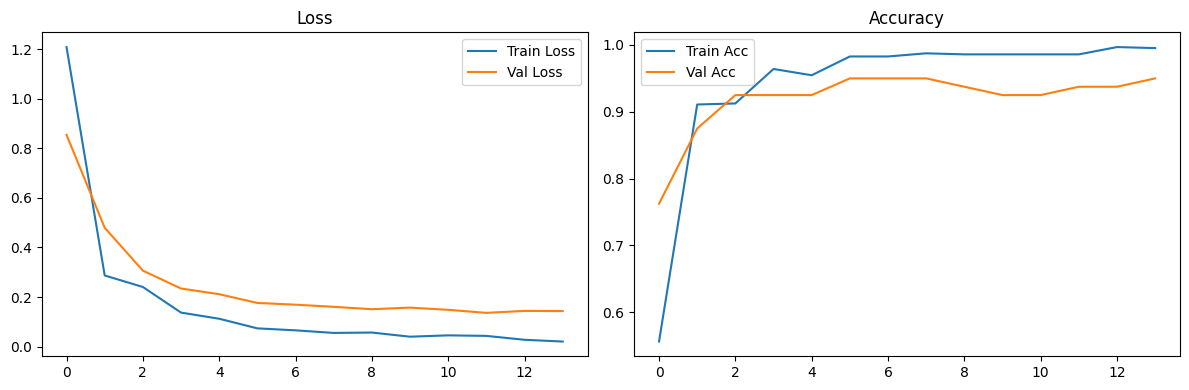

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

## Evaluation

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}')

y_pred = np.argmax(model.predict(X_test), axis=1)
print()
print(classification_report(y_test, y_pred, target_names=classes))

3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.9625 - loss: 0.0780
Test Loss: 0.0780, Test Accuracy: 0.9625
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step

              precision    recall  f1-score   support

       dress       0.95      1.00      0.98        20
       pants       0.95      0.95      0.95        20
       shirt       1.00      0.95      0.97        20
       shoes       0.95      0.95      0.95        20

    accuracy                           0.96        80
   macro avg       0.96      0.96      0.96        80
weighted avg       0.96      0.96      0.96        80



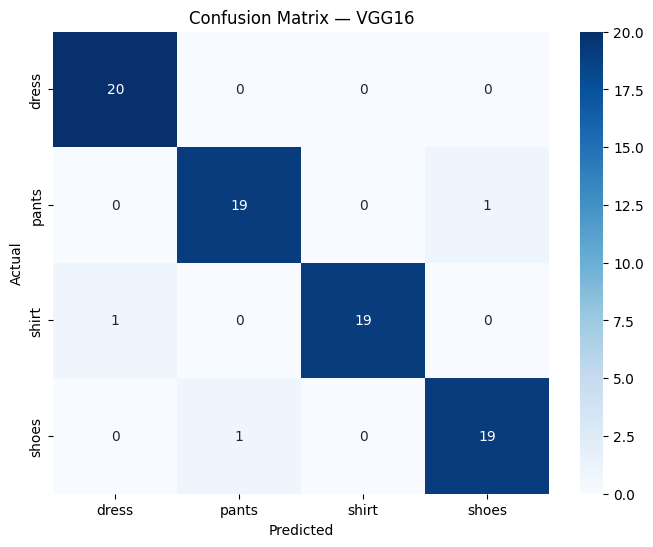

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — VGG16')
plt.show()